<a href="https://colab.research.google.com/github/ButenkoYuliia/customer-segmentation/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation of an Online Store (K-Means)

**Author:** Yuliia Butenko  
**Tools:** SQL (Google BigQuery), Python (pandas, scikit-learn, matplotlib), Tableau

## 1. Goal

Split the store's customers into groups with similar behaviour, so that marketing can
address each group differently instead of sending the same message to everyone.

**Business questions:**
1. Which types of customers does the store have?
2. How do they react to email marketing?
3. Where are the biggest opportunities and risks?

## 2. Data

Source: the course dataset `DA` in Google BigQuery (e-commerce store, Nov 2020 – Jan 2021).

Tables used: `order`, `product`, `session`, `session_params`, `account`, `account_session`,
`email_sent`, `email_open`, `email_visit`.

One row of the final table = one registered customer (**2,781 customers**).
The SQL queries are in the files `rfm_step1.sql` and `segmentation_step2.sql`.

| Feature | Meaning |
|---|---|
| `order_sum` | order value |
| `emails_sent` / `emails_opened` / `emails_visited` | emails received / opened / clicked through to the site |
| `open_rate`, `visit_rate` | share of opened / clicked emails |
| `is_verified`, `is_unsubscribed`, `send_interval` | account status |
| `device`, `channel`, `country`, `continent` | descriptive fields (not used in the model) |

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# CSV exported from BigQuery (result of segmentation_step2.sql)
df = pd.read_csv('segmentation_features.csv')
print(df.shape)
df.head()

(2781, 18)


,account_id,order_date,order_sum,items_cnt,categories_cnt,avg_item_price,emails_sent,emails_opened,emails_visited,open_rate,visit_rate,is_verified,is_unsubscribed,send_interval,device,channel,continent,country
0,665856,2020-12-03,8900.0,1,1,8900.0,11,11,3,1.000,0.273,1,1,1,desktop,Direct,Asia,Taiwan
1,646438,2020-12-30,8900.0,1,1,8900.0,0,0,0,NaN,NaN,1,0,1,mobile,Direct,Americas,Canada
2,663113,2020-11-02,8495.0,1,1,8495.0,112,27,15,0.241,0.134,1,0,1,desktop,Organic Search,Europe,Italy
3,647605,2020-11-10,8395.0,1,1,8395.0,0,0,0,NaN,NaN,1,0,1,tablet,Paid Search,Americas,United States
4,646055,2020-11-25,8356.0,1,1,8356.0,0,0,0,NaN,NaN,1,0,1,mobile,Organic Search,Americas,Canada


## 3. Why classic RFM analysis did not work

The original plan was an **RFM analysis** (Recency, Frequency, Monetary).
A data check showed that **every customer has exactly one order**:
in this dataset each account is linked to only one session — the one where it was created.
Repeat purchases cannot be traced, so *Frequency = 1* for all customers and
*Recency* is simply the date of the only order.

**Decision:** instead of RFM, use features of order value and **email engagement**.

In [7]:
print(df.describe().round(2).T)

for col in ['items_cnt', 'categories_cnt']:
    print(f'\n{col}:', df[col].value_counts().to_dict())

                  count       mean       std       min        25%        50%  \
account_id       2781.0  658815.53  13140.19  636138.0  647432.00  658322.00   
order_sum        2781.0     928.63   1319.68       3.0     150.00     399.00   
items_cnt        2781.0       1.00      0.00       1.0       1.00       1.00   
categories_cnt   2781.0       1.00      0.00       1.0       1.00       1.00   
avg_item_price   2781.0     928.63   1319.68       3.0     150.00     399.00   
emails_sent      2781.0      19.09     39.26       0.0       0.00       0.00   
emails_opened    2781.0       6.99     20.82       0.0       0.00       0.00   
emails_visited   2781.0       0.78      2.92       0.0       0.00       0.00   
open_rate        1038.0       0.37      0.38       0.0       0.01       0.22   
visit_rate       1038.0       0.04      0.09       0.0       0.00       0.00   
is_verified      2781.0       0.72      0.45       0.0       0.00       1.00   
is_unsubscribed  2781.0       0.16      

## 4. Feature selection

Findings from the data check:

- `items_cnt` and `categories_cnt` are **1 for every customer** → no information, dropped.
- `avg_item_price` is identical to `order_sum` (one item per order) → dropped.
- `order_sum` is strongly skewed (median ≈ 400, maximum ≈ 8,900) → log transform.
- **Only 1,038 of 2,781 customers (37%) ever received an email.**
  The other 1,743 form their own segment, **"No Email"**, without a model —
  otherwise K-Means would simply split customers into "received emails" vs "did not".

**Model features** (customers with emails only):
`log(order_sum)`, `log(emails_sent)`, `open_rate`, `visit_rate` — all standardised,
because they are measured in very different units.

In [8]:
em = df[df['emails_sent'] > 0].copy()
print('Customers with emails:', len(em))
print('Customers without emails:', (df['emails_sent'] == 0).sum())

em['log_order_sum'] = np.log1p(em['order_sum'])
em['log_emails_sent'] = np.log1p(em['emails_sent'])

features = ['log_order_sum', 'log_emails_sent', 'open_rate', 'visit_rate']
X_scaled = StandardScaler().fit_transform(em[features])

Customers with emails: 1038
Customers without emails: 1743


## 5. Choosing the number of clusters (k)

Two methods: the **elbow method** (inertia) and the **silhouette score**.

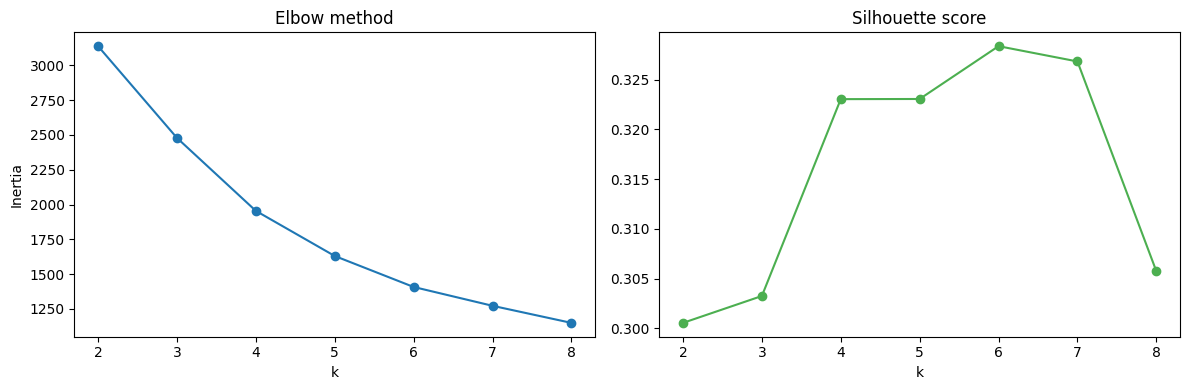

 k  silhouette
 2       0.301
 3       0.303
 4       0.323
 5       0.323
 6       0.328
 7       0.327
 8       0.306


In [9]:
ks = range(2, 9)
inertia, silhouette = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertia, marker='o')
axes[0].set_title('Elbow method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(ks, silhouette, marker='o', color='#4CAF50')
axes[1].set_title('Silhouette score'); axes[1].set_xlabel('k')
plt.tight_layout(); plt.show()

print(pd.DataFrame({'k': ks, 'silhouette': np.round(silhouette, 3)}).to_string(index=False))

The elbow is soft: after **k = 4** the gain drops noticeably.
Silhouette is almost the same for k = 4, 5 and 6 (≈ 0.32–0.33),
so **k = 4** is chosen as the simplest solution that is easy to explain to the business.

A silhouette of ≈ 0.3 means a **moderate** structure: the groups are distinguishable,
but the borders between them are not sharp — typical for behavioural customer data.

In [10]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
em['cluster'] = km.fit_predict(X_scaled)

profile = em.groupby('cluster').agg(
    clients=('account_id', 'count'),
    order_sum_median=('order_sum', 'median'),
    emails_sent_median=('emails_sent', 'median'),
    open_rate=('open_rate', 'mean'),
    visit_rate=('visit_rate', 'mean'),
).round(2)

# Name clusters by their profile (robust to cluster numbering)
names = {}
names[profile['visit_rate'].idxmax()] = 'Active Clickers'
rest = profile.drop(index=list(names))
names[rest['emails_sent_median'].idxmin()] = 'Unverified'
rest = rest.drop(index=list(names), errors='ignore')
names[rest['open_rate'].idxmax()] = 'Readers'
names[rest['open_rate'].idxmin()] = 'Ignorers'

em['segment'] = em['cluster'].map(names)
profile.index = profile.index.map(names)
profile

,clients,order_sum_median,emails_sent_median,open_rate,visit_rate
cluster,,,,,
Readers,246,449.5,43.5,0.90,0.03
Unverified,272,462.5,3.0,0.15,0.00
Ignorers,457,499.0,73.0,0.15,0.03
Active Clickers,63,255.0,21.0,0.81,0.33


In [11]:
status = em.groupby('segment')[['is_unsubscribed', 'is_verified', 'send_interval']].mean().round(2)
devices = pd.crosstab(em['segment'], em['device'], normalize='index').round(2)
display(status)
display(devices)

,is_unsubscribed,is_verified,send_interval
segment,,,
Active Clickers,0.37,1.00,1.22
Ignorers,0.07,1.00,1.10
Readers,0.20,0.85,1.11
Unverified,0.10,0.29,1.02


device,desktop,mobile,tablet
segment,,,
Active Clickers,0.57,0.38,0.05
Ignorers,0.59,0.40,0.02
Readers,0.57,0.40,0.03
Unverified,0.64,0.35,0.01


## 6. Segment profiles

| Segment | Customers | Order (median) | Emails | Opened | Clicked | Unsubscribed | Verified |
|---|---|---|---|---|---|---|---|
| **No Email** | 1,743 | – | 0 | – | – | – | – |
| **Ignorers** | 457 | 499 | 73 | 15% | 3% | 7% | 100% |
| **Unverified** | 272 | 463 | 3 | 15% | 0% | 10% | 29% |
| **Readers** | 246 | 450 | 44 | 90% | 3% | 20% | 85% |
| **Active Clickers** | 63 | 255 | 21 | 81% | 33% | 37% | 100% |

- **Ignorers** — the largest email segment: they receive the most emails but rarely open them.
- **Unverified** — received very few emails because most of them never confirmed their email address.
- **Readers** — open almost every email but hardly ever click through to the site.
- **Active Clickers** — the most engaged group, yet with the smallest orders and the highest unsubscribe rate.

The order value is almost the same in three of the four segments, so the groups differ
mainly in **email behaviour**, not in purchase size. Device usage is also similar in all
segments (≈ 60% desktop, 40% mobile), so the device does not explain the segments.

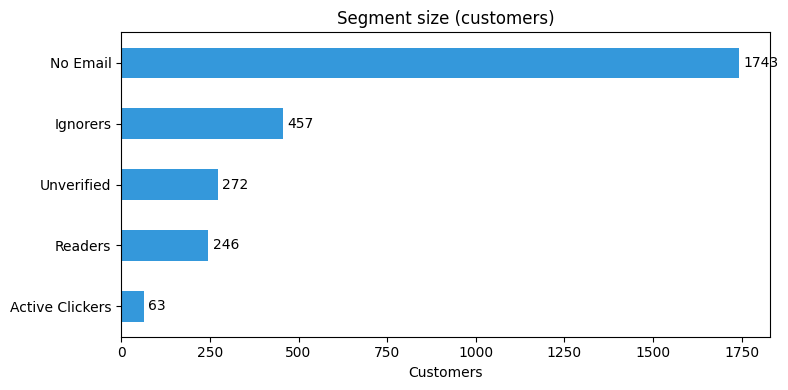

In [12]:
sizes = em['segment'].value_counts()
sizes['No Email'] = (df['emails_sent'] == 0).sum()

ax = sizes.sort_values().plot(kind='barh', color='#3498db', figsize=(8, 4))
ax.bar_label(ax.containers[0], padding=3)
plt.title('Segment size (customers)'); plt.ylabel(''); plt.xlabel('Customers')
plt.tight_layout(); plt.show()

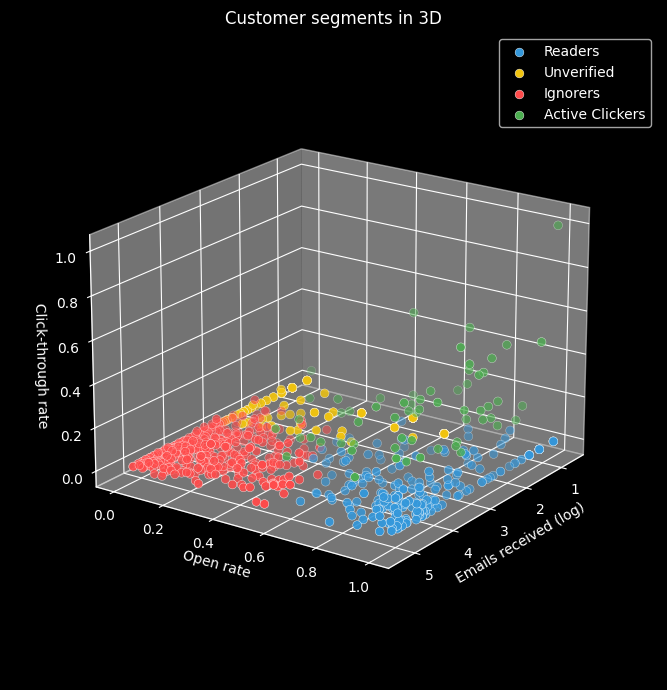

In [13]:
colors = {'Readers': '#3498db', 'Unverified': '#f1c40f',
          'Ignorers': '#ff4b4b', 'Active Clickers': '#4CAF50'}

with plt.style.context('dark_background'):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    for seg, color in colors.items():
        part = em[em['segment'] == seg]
        ax.scatter(part['log_emails_sent'], part['open_rate'], part['visit_rate'],
                   c=color, s=40, edgecolor='white', linewidth=0.3, label=seg)
    ax.set_xlabel('Emails received (log)')
    ax.set_ylabel('Open rate')
    ax.set_zlabel('Click-through rate')
    ax.set_box_aspect(None, zoom=0.85)
    ax.legend(); ax.view_init(elev=20, azim=35)
    plt.title('Customer segments in 3D')
    plt.tight_layout(); plt.show()

## 7. Conclusions

1. **63% of buyers are not reached by email marketing at all** ("No Email").
   This is the largest untapped potential.
2. **A hypothesis was rejected by the data:** "Ignorers" unsubscribe *least* (7%).
   Cause and effect are reversed here — people who unsubscribe stop receiving emails,
   so the customers with the most emails are exactly those who never unsubscribed.
3. **The most engaged customers leave most often:** "Active Clickers" have the highest
   unsubscribe rate (37%). The data does not show why — this needs further investigation.
4. **The "Unverified" segment is a technical problem, not a behavioural one:**
   only 29% confirmed their email address.

## 8. Recommendations

| Segment | Recommendation |
|---|---|
| No Email | Invite buyers to subscribe after the purchase (e.g. discount for subscription). |
| Unverified | Send a reminder to confirm the email address. |
| Ignorers | Reduce frequency, test new subject lines, re-engagement campaign. |
| Readers | Improve calls-to-action in emails: buttons, offers, links. |
| Active Clickers | Upsell offers; survey on unsubscribe reasons. |

## 9. Limitations

- Only one session per account → repeat purchases and true customer lifetime are not visible.
- Short period (about three months).
- `is_unsubscribed` is a final status; the time of unsubscribing is unknown.
- Silhouette ≈ 0.3 → segments are useful for marketing, but their borders are soft.

In [14]:
# Export for Tableau: all customers with their segment
out = df.copy()
out['segment'] = 'No Email'
out.loc[em.index, 'segment'] = em['segment']
out.to_csv('customer_segments.csv', index=False)
print(out['segment'].value_counts())

segment
No Email           1743
Ignorers            457
Unverified          272
Readers             246
Active Clickers      63
Name: count, dtype: int64
